<a href="https://colab.research.google.com/github/sungmin-Jeon/financial_practice-/blob/main/notebooks/Spurious_mean-reversion%20and%20regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import statsmodels.api as sm

# Spurious mean-reversion

In [45]:
def one_trial(T=120, mu=0.01, sigma=0.08, P0=100, seed=None):
    if seed is not None:
        np.random.seed(seed)

    # monthly log returns
    eps = np.random.normal(0, 1, T)
    R = mu + sigma * eps

    # log price 생성
    logP = np.empty(T + 1)
    logP[0] = np.log(P0)

    for t in range(1, T + 1):
        logP[t] = logP[t-1] + R[t - 1]

    # 회귀용 데이터
    y = R
    x = logP[:-1]
    X = sm.add_constant(x)

    model = sm.OLS(y, X).fit()

    a_hat = model.params[0]
    b_hat = model.params[1]

    return {
        "R": R,
        "logP": logP,
        "a_hat": a_hat,
        "b_hat": b_hat,
        "model": model
    }

In [46]:
result = one_trial(T=120, mu=0.01, sigma=0.08, P0=100, seed=42)

print("a_hat =", result["a_hat"])
print("b_hat =", result["b_hat"])
print(result["model"].summary())

a_hat = 0.19633115136258555
b_hat = -0.041654768394979946
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.829
Date:                Mon, 20 Apr 2026   Prob (F-statistic):              0.179
Time:                        10:10:45   Log-Likelihood:                 143.55
No. Observations:                 120   AIC:                            -283.1
Df Residuals:                     118   BIC:                            -277.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

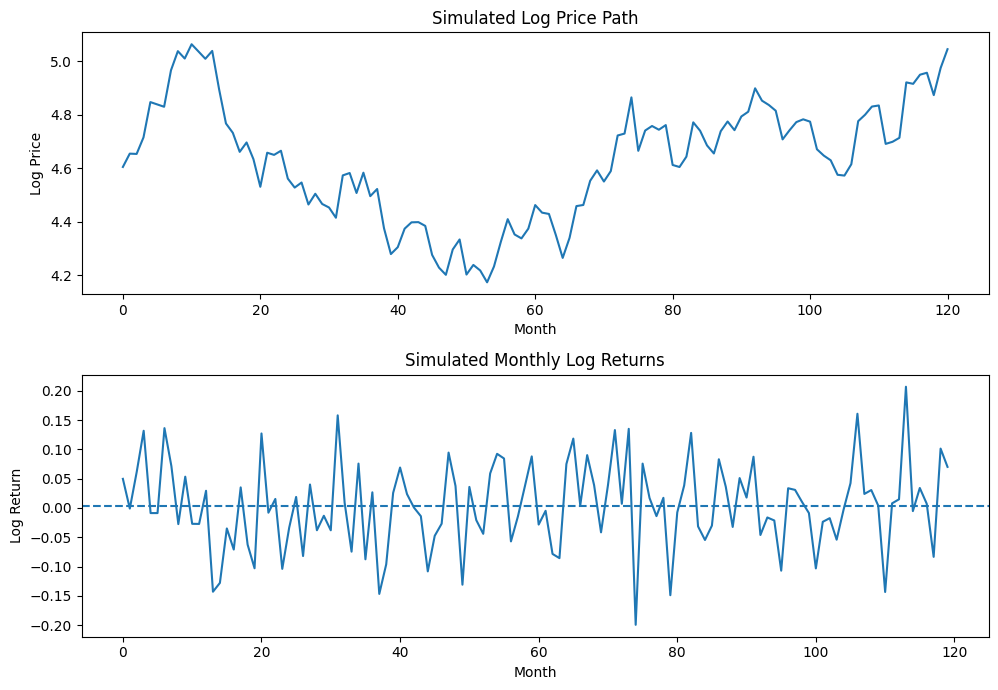

In [51]:
logP_data = result["logP"]

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(logP_data)
axes[0].set_title("Simulated Log Price Path")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Log Price")

axes[1].plot(result["R"])
axes[1].axhline(result["R"].mean(), linestyle='--')
axes[1].set_title("Simulated Monthly Log Returns")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Log Return")

plt.tight_layout()
plt.show()

In [52]:
# -----------------------------
# 3. Monte Carlo 반복
# -----------------------------
def monte_carlo_experiment(N=100, T=120, mu=0.01, sigma=0.08, P0=100):
    a_list = []
    b_list = []
    t_list = []
    p_list = []

    for i in range(N):
        result = one_trial(T=T, mu=mu, sigma=sigma, P0=P0, seed=None)
        model = result["model"]

        a_list.append(result["a_hat"])
        b_list.append(result["b_hat"])
        t_list.append(model.tvalues[1])
        p_list.append(model.pvalues[1])

    return pd.DataFrame({
        "a_hat": a_list,
        "b_hat": b_list,
        "t_stat_b": t_list,
        "p_value_b": p_list
    })


mc_df = monte_carlo_experiment(N=5000, T=120, mu=0.01, sigma=0.08, P0=100)

mc_df.describe()

,a_hat,b_hat,t_stat_b,p_value_b
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.151157,-0.028082,-1.188678,0.314382
std,0.148303,0.031385,0.978006,0.291437
min,-0.132791,-0.306024,-4.589540,0.000011
25%,0.052289,-0.040353,-1.867212,0.063932
50%,0.115663,-0.019927,-1.229287,0.215091
75%,0.212800,-0.007454,-0.532832,0.515767
max,1.385664,0.030212,2.487764,0.999774


In [53]:
print("평균 a_hat:", mc_df["a_hat"].mean())
print("평균 b_hat:", mc_df["b_hat"].mean())
print("b 유의확률 5% 미만 비율:", (mc_df["p_value_b"] < 0.05).mean())
print("평균 |t-stat|:", mc_df["t_stat_b"].abs().mean())

평균 a_hat: 0.15115698869310448
평균 b_hat: -0.028082310328752608
b 유의확률 5% 미만 비율: 0.2178
평균 |t-stat|: 1.3069803204587727


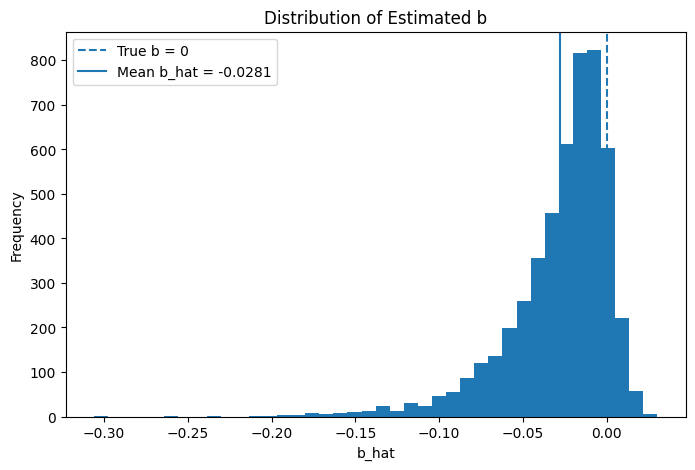

In [54]:
plt.figure(figsize=(8, 5))
plt.hist(mc_df["b_hat"], bins=40)
plt.axvline(0, linestyle='--', label='True b = 0')
plt.axvline(mc_df["b_hat"].mean(), linestyle='-', label=f"Mean b_hat = {mc_df['b_hat'].mean():.4f}")
plt.title("Distribution of Estimated b")
plt.xlabel("b_hat")
plt.ylabel("Frequency")
plt.legend()
plt.show()

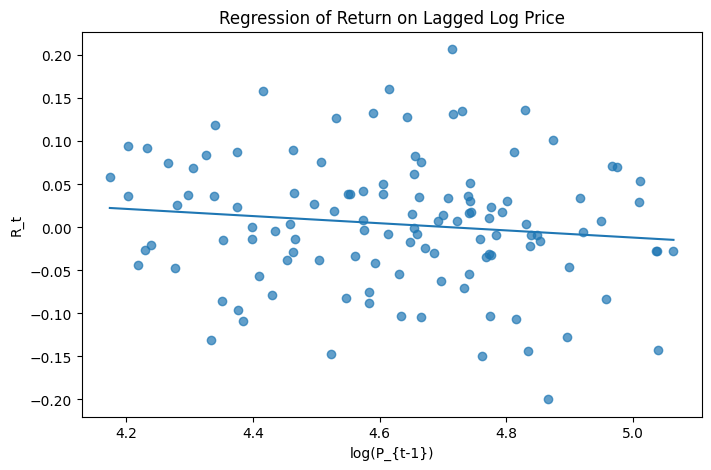

In [55]:
x = result["logP"][:-1]
y = result["R"]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.7)
plt.xlabel("log(P_{t-1})")
plt.ylabel("R_t")
plt.title("Regression of Return on Lagged Log Price")

# 회귀선
b0 = result["model"].params[0]
b1 = result["model"].params[1]
x_line = np.linspace(x.min(), x.max(), 100)
y_line = b0 + b1 * x_line
plt.plot(x_line, y_line)

plt.show()

# Spurious regression

In [42]:
from statsmodels.graphics.tsaplots import plot_acf

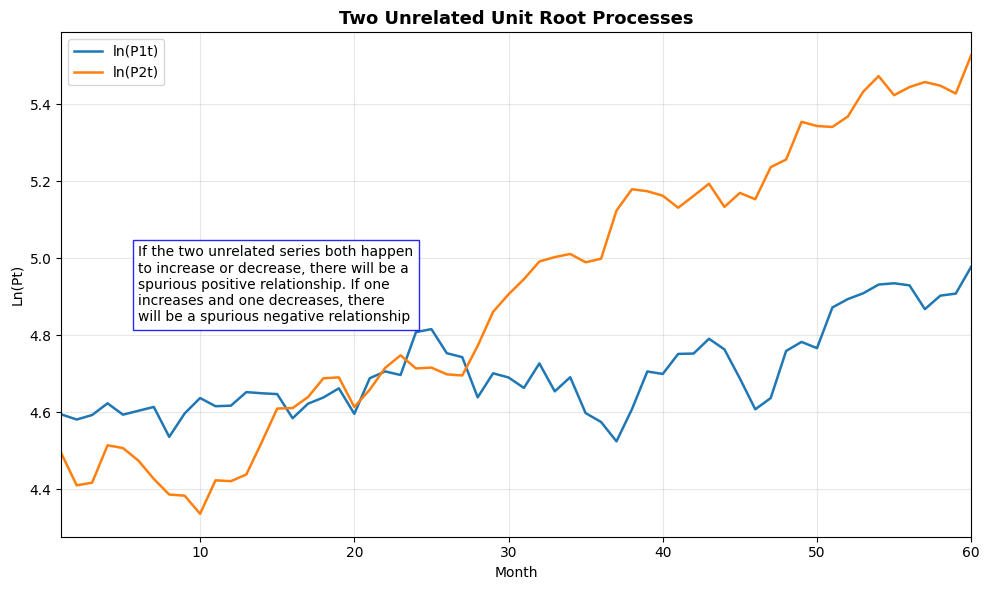

One Regression Result
Intercept (a): 3.5745
Slope (b):     0.2305
t-stat of b:   8.2915
p-value of b:  0.0000
R-squared:     0.5424



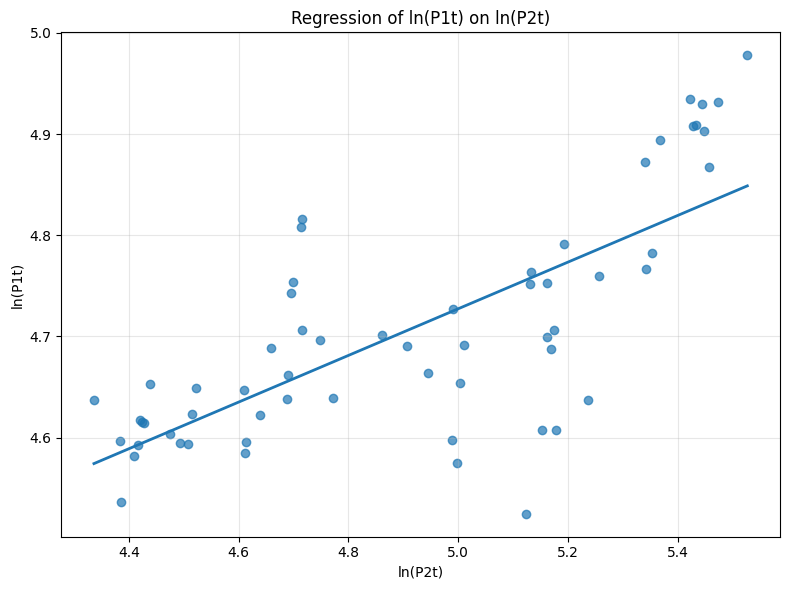

Monte Carlo Summary
Average a:        2.2527
Average b:        0.5257
Average t-stat:   6.7745
Average |t-stat|: 7.6352
Average R^2:      0.4110



<Figure size 800x400 with 0 Axes>

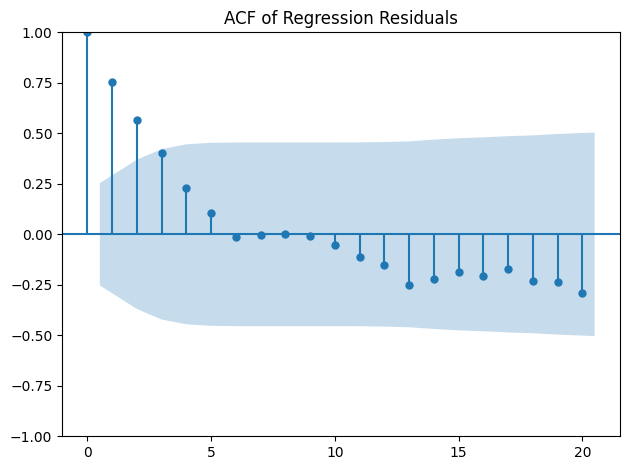

=== Regression in First Differences ===
Intercept (a): 0.0040
Slope (b):     0.1409
t-stat of b:   0.9648
p-value of b:  0.3387
R-squared:     0.0161

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9308
Date:                Mon, 20 Apr 2026   Prob (F-statistic):              0.339
Time:                        10:03:22   Log-Likelihood:                 91.178
No. Observations:                  59   AIC:                            -178.4
Df Residuals:                      57   BIC:                            -174.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|     

In [43]:
# 설정
np.random.seed(7)

T = 60
N = 100
log_p1_0 = 4.5
log_p2_0 = 4.5

mu1, mu2 = 0.01, 0.012
sigma1 = sigma2 = 0.05


# random work 생성
def generate_unrelated_unit_root_processes(T, log_p1_0=4.5, log_p2_0=4.5,
                                           mu1=0.01, mu2=0.012,
                                           sigma1=0.05, sigma2=0.05):
    e1 = np.random.normal(0, 1, T)
    e2 = np.random.normal(0, 1, T)

    r1 = mu1 + sigma1 * e1
    r2 = mu2 + sigma2 * e2

    log_p1 = log_p1_0 + np.cumsum(r1)
    log_p2 = log_p2_0 + np.cumsum(r2)

    return log_p1, log_p2, r1, r2


# OLS 회귀
def run_regression(y, x):
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    return model


# 시각화
log_p1, log_p2, r1, r2 = generate_unrelated_unit_root_processes(
    T=T,
    log_p1_0=log_p1_0,
    log_p2_0=log_p2_0,
    mu1=mu1, mu2=mu2,
    sigma1=sigma1, sigma2=sigma2
)

months = np.arange(1, T + 1)

plt.figure(figsize=(10, 6))
plt.plot(months, log_p1, label='ln(P1t)', linewidth=1.8)
plt.plot(months, log_p2, label='ln(P2t)', linewidth=1.8)

plt.title('Two Unrelated Unit Root Processes', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Ln(Pt)')
plt.xlim(1, T)
plt.grid(True, alpha=0.3)
plt.legend()

text_str = (
    "If the two unrelated series both happen\n"
    "to increase or decrease, there will be a\n"
    "spurious positive relationship. If one\n"
    "increases and one decreases, there\n"
    "will be a spurious negative relationship"
)

plt.text(
    6, min(log_p1.min(), log_p2.min()) + 0.5,
    text_str,
    fontsize=10,
    bbox=dict(facecolor='white', edgecolor='blue', alpha=0.85)
)

plt.tight_layout()
plt.show()


# 한 번 회귀
model = run_regression(log_p1, log_p2)

print("One Regression Result")
print(f"Intercept (a): {model.params[0]:.4f}")
print(f"Slope (b):     {model.params[1]:.4f}")
print(f"t-stat of b:   {model.tvalues[1]:.4f}")
print(f"p-value of b:  {model.pvalues[1]:.4f}")
print(f"R-squared:     {model.rsquared:.4f}")
print()

# 회귀선 포함 산점도
plt.figure(figsize=(8, 6))
plt.scatter(log_p2, log_p1, alpha=0.7)
x_line = np.linspace(log_p2.min(), log_p2.max(), 100)
y_line = model.params[0] + model.params[1] * x_line
plt.plot(x_line, y_line, linewidth=2)

plt.title('Regression of ln(P1t) on ln(P2t)')
plt.xlabel('ln(P2t)')
plt.ylabel('ln(P1t)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# MC 반복
a_list = []
b_list = []
t_list = []
abs_t_list = []
r2_list = []

for _ in range(N):
    log_p1_mc, log_p2_mc, _, _ = generate_unrelated_unit_root_processes(
        T=T,
        log_p1_0=log_p1_0,
        log_p2_0=log_p2_0,
        mu1=mu1, mu2=mu2,
        sigma1=sigma1, sigma2=sigma2
    )
    mc_model = run_regression(log_p1_mc, log_p2_mc)

    a_list.append(mc_model.params[0])
    b_list.append(mc_model.params[1])
    t_list.append(mc_model.tvalues[1])
    abs_t_list.append(abs(mc_model.tvalues[1]))
    r2_list.append(mc_model.rsquared)

print("Monte Carlo Summary")
print(f"Average a:        {np.mean(a_list):.4f}")
print(f"Average b:        {np.mean(b_list):.4f}")
print(f"Average t-stat:   {np.mean(t_list):.4f}")
print(f"Average |t-stat|: {np.mean(abs_t_list):.4f}")
print(f"Average R^2:      {np.mean(r2_list):.4f}")
print()


# Redisual ACF
residuals = model.resid

plt.figure(figsize=(8, 4))
plot_acf(residuals, lags=20)
plt.title("ACF of Regression Residuals")
plt.tight_layout()
plt.show()


# 차분 후 다시 회귀
dlog_p1 = np.diff(log_p1)
dlog_p2 = np.diff(log_p2)

diff_model = run_regression(dlog_p1, dlog_p2)

print("=== Regression in First Differences ===")
print(f"Intercept (a): {diff_model.params[0]:.4f}")
print(f"Slope (b):     {diff_model.params[1]:.4f}")
print(f"t-stat of b:   {diff_model.tvalues[1]:.4f}")
print(f"p-value of b:  {diff_model.pvalues[1]:.4f}")
print(f"R-squared:     {diff_model.rsquared:.4f}")
print()

print(diff_model.summary())